In [47]:
#Import necessary libraries (e.g., pandas, numpy)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

In [48]:
# load data
dataset = "WineQT.csv" # read  file
#Read the CSV file into a dataframe.
df = pd.read_csv(dataset)

In [49]:
# drop missing values
print(df.isnull().sum())
df = df.dropna()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


In [50]:
# Count duplicate rows
print("Duplicate rows: ", df.duplicated().sum())  
# Returns number of duplicate records
# Display duplicate rows
print(df[df.duplicated()]) 
# Shows duplicated entries
df = df.drop_duplicates()
# ^ If there are duplicates this code drops them 

Duplicate rows:  0
Empty DataFrame
Columns: [fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, alcohol, quality, Id]
Index: []


In [51]:
# Define the target variable.
target = "quality"

In [52]:
# Convert the quality label into a binary variable:
# quality ≥ 6 → good wine
# quality < 6 → bad wine
df["quality_label"] = df["quality"].apply(lambda x: 1 if x >= 6 else 0)

In [53]:
# 2. Split Features and Labels
# Separate the dataset into:
# X input features
# Y target labels
X = df.drop(columns=["quality_label"])
y = df["quality_label"]

In [54]:
# standardize the Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [55]:
# Build the Pipeline: t-SNE Representation
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca"
)

X_tsne = tsne.fit_transform(X_scaled)


# Dataframe
tsne_df = pd.DataFrame(X_tsne, columns=["tsne1","tsne2"])
tsne_df["label"] = y.values

In [56]:
# Choose for K-Means Using Silhouette Score (t-SNE Space)
k_values = [2,3,4,5,6]
scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X_tsne)

    score = silhouette_score(X_tsne, cluster_labels)
    scores.append(score)

    print(f"K = {k} Silhouette Score = {score:.4f}")

K = 2 Silhouette Score = 0.3640
K = 3 Silhouette Score = 0.4467
K = 4 Silhouette Score = 0.3981
K = 5 Silhouette Score = 0.4032
K = 6 Silhouette Score = 0.4224


In [57]:
# Select the value of k that yields the highest silhouette score
highest_k = k_values[scores.index(max(scores))]
print("Highest K = ", highest_k)

Highest K =  3


In [58]:
# 6. Cluster in t-SNE Space
# Fit K-Means using the selected k
kmeans = KMeans(n_clusters=highest_k, random_state=42)
# Obtain cluster labels.
clusters = kmeans.fit_predict(X_tsne)
# Augment the t-SNE features with the cluster labels.
tsne_df["cluster"] = clusters

In [59]:
X_final = tsne_df[["tsne1", "tsne2", "cluster"]]
y_final = tsne_df["label"]

In [60]:
# 7. Train Supervised Models
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [61]:
# logistic Regression
LR = LogisticRegression(max_iter=10000)
LR.fit(X_train, y_train)
LR_pred = LR.predict(X_test)
LR_proba = LR.predict_proba(X_test)[:, 1]

In [62]:
# Support Vector Machine (SVM)
SVM = SVC(probability=True)
SVM.fit(X_train, y_train)
SVM_pred = SVM.predict(X_test)
SVM_proba = SVM.predict_proba(X_test)[:, 1]

In [63]:
# Random Forest
RF = RandomForestClassifier(random_state=42)
RF.fit(X_train, y_train)
RF_pred = RF.predict(X_test)
RF_proba = RF.predict_proba(X_test)[:, 1]

In [64]:
# 8. Evaluation
def evaluate(name, y_test, y_pred, y_proba):
    print(f"\n{name}")
    print("Accuracy: ", accuracy_score(y_test, y_pred))
    print("F1-score: ", f1_score(y_test, y_pred))
    print("ROC-AUC: ", roc_auc_score(y_test, y_proba))

evaluate("Logistic Regression", y_test, LR_pred, LR_proba)
evaluate("SVM", y_test, SVM_pred, SVM_proba)
evaluate("Random Forest", y_test, RF_pred, RF_proba)


Logistic Regression
Accuracy:  1.0
F1-score:  1.0
ROC-AUC:  1.0

SVM
Accuracy:  0.6375545851528385
F1-score:  0.7381703470031545
ROC-AUC:  0.6312721939169368

Random Forest
Accuracy:  1.0
F1-score:  1.0
ROC-AUC:  1.0


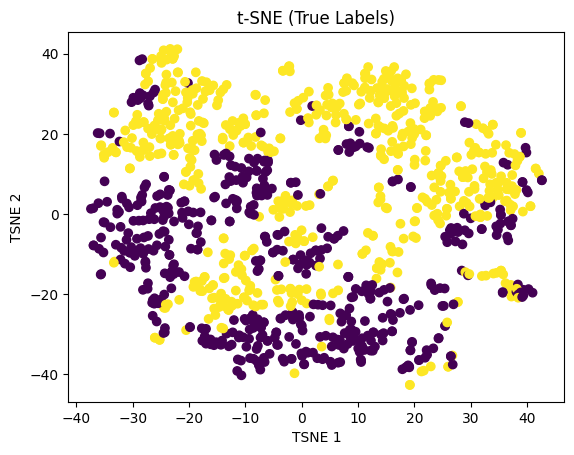

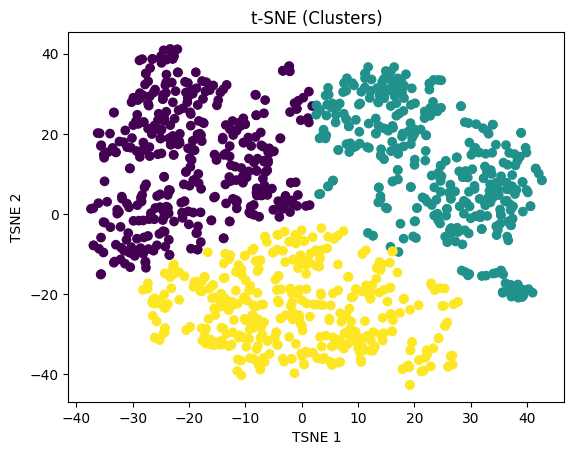

In [65]:
# 9. Visualization
# true label
plt.scatter(tsne_df["tsne1"], tsne_df["tsne2"], c=tsne_df["label"])
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")
plt.title("t-SNE (True Labels)")
plt.show()

# clusters
plt.scatter(tsne_df["tsne1"], tsne_df["tsne2"], c=tsne_df["cluster"])
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")
plt.title("t-SNE (Clusters)")
plt.show()